# Cómo desidentificar PII en documentos legales españoles antes de usar un LLM

Si quieres usar un modelo para revisar, clasificar o resumir documentación legal, el bloqueo suele ser el mismo: nombres, direcciones, DNIs, teléfonos y correos no deberían salir de tu entorno sin control.

Este notebook monta un pipeline donde el preprocesado sensible ocurre en local y el modelo cloud solo ve texto ya anonimizado.

Flujo:
1. **OCR local** con LightOnOCR en Ollama para extraer texto del PDF.
2. **Detección de PII** con Presidio y recognizers específicos para España.
3. **Anonimización reversible** con tokens estables como `<PERSON_1>` o `<ORGANIZATION_2>`.
4. **LLM cloud sobre texto desidentificado** para analizar el documento sin exponer el dato real.
5. **Deanonimización final** para devolver la respuesta con los valores originales cuando haga falta.

> OCR, detección y anonimización corren en local. Solo sale de la máquina el texto ya desidentificado.


## Configuración

Instala dependencias y deja preparados los modelos locales:

```bash
pip install langchain langchain-ollama langchain-openrouter liteparse python-dotenv
pip install presidio-analyzer presidio-anonymizer spacy pydni
python -m spacy download es_core_news_sm
# Ollama con gemma4:e4b y lightonocr-2-1b cargados
```

Antes de ejecutar:
- apunta `NOTA_SIMPLE` al PDF que quieras procesar
- arranca Ollama en `http://localhost:11434`
- define `OPENROUTER_API_KEY` si vas a ejecutar el paso cloud


In [16]:
from presidio_analyzer import AnalyzerEngine, RecognizerRegistry, EntityRecognizer, RecognizerResult, Pattern, PatternRecognizer
from presidio_analyzer.nlp_engine import NlpEngineProvider
from presidio_anonymizer import AnonymizerEngine
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
from liteparse import LiteParse
from langchain_openrouter import ChatOpenRouter
from pydantic import BaseModel, Field
from PyDNI import verificar_dni, verificar_nie, verificar_cif
from IPython.display import Markdown, display
from dotenv import load_dotenv
import base64, json, os, re
import io
from PIL import Image

load_dotenv()


False

In [17]:
OLLAMA_URL = "http://localhost:11434"
OCR_MODEL = "lightonocr-2-1b"
LLM_MODEL = "gemma4:e4b"
NOTA_SIMPLE = "/Users/ivor/Downloads/01662CS.pdf"  # Sustituye por el PDF que quieras procesar


## 1. OCR local del PDF

Primero convertimos una página del PDF en imagen y la pasamos por LightOnOCR en Ollama.

Aquí todavía no hay clasificación ni extracción de entidades: solo queremos obtener texto estructurado de forma local para trabajar el resto del pipeline sobre una base legible.


In [18]:
parser = LiteParse()
screenshot = parser.screenshot(NOTA_SIMPLE, dpi=200, load_bytes=True)
b64 = base64.b64encode(screenshot.get_page(105).image_bytes).decode()

ocr_llm = ChatOllama(
    model=OCR_MODEL,
    base_url=OLLAMA_URL,
    temperature=0,       # deterministic — OCR must not hallucinate
    num_ctx=16384,
    top_k=40,
    top_p=0.95,
    repeat_penalty=1.1,
    num_predict=16384,
)

msg = HumanMessage(content=[
    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
    {"type": "text", "text": "Transcribe todo el texto de esta imagen exactamente como aparece, sin comentarios ni formato adicional."},
])

response = ocr_llm.invoke([msg])
content = response.content

print(f'Content length: {len(content)}')
display(Markdown(content))


Content length: 5900


 No se ha incluido ningún comentario ni explicaciones.

---

**ST Sociedad de Tasación**

*Valores, Comunidades y Tecnología*

Nº Informe ST: PA-25644/T 1/03/2024  
Refer. Entidad: BARCO BUVA N° Ofic: 5334  
Posición:  

---

# CERTIFICADO DE TASACIÓN

## MÉTODOS UTILIZADOS VALORES AL 11/03/2024:

<table>
  <tr>
    <th>Elemento valorado</th>
    <td>TIVvs</td>
    <td>23798</td>
    <td>31Apa</td>
    <td>43Apa</td>
  </tr>
  <tr>
    <th>Superficie (m²)</th>
    <td>116.26</td>
    <td>900</td>
    <td>25.00</td>
    <td>30.00</td>
  </tr>
  <tr>
    <th>Peso capital / IDUFIR</th>
    <td>32707</td>
    <td>32797</td>
    <td>85641</td>
    <td>80992</td>
  </tr>
  <tr>
    <th>Válor del suelo (€)</th>
    <td>134.52,24</td>
    <td>27000</td>
    <td>75000</td>
    <td>90000</td>
  </tr>
  <tr>
    <th>Válor interno (gustado) (t)</th>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <th>Código correspondiente actual (€)</th>
    <td>205.971,02</td>
    <td>4.276,80</td>
    <td>11.370,72</td>
    <td>14.258,80</td>
  </tr>
  <tr>
    <th>Válor por comparación anualidad</th>
    <td>262.385,62</td>
    <td>4.300,00</td>
    <td>16.961,36</td>
    <td>18.623,09</td>
  </tr>
  <tr>
    <th>Válor por comparación anualidad (t)</th>
    <td>3.131,13</td>
    <td>477,78</td>
    <td>562,46</td>
    <td>620,30</td>
  </tr>
</table>

## VALOR POR FINCAS

<table>
  <tr>
    <th>Elemento valorado</th>
    <td>TIVvs</td>
    <td>23798</td>
    <td>31Apa</td>
    <td>43Apa</td>
  </tr>
  <tr>
    <th>Peso capital / IDUFIR</th>
    <td>32707</td>
    <td>32797</td>
    <td>85641</td>
    <td>80992</td>
  </tr>
  <tr>
    <th>Válor del suelo (€)</th>
    <td>134.52,24</td>
    <td>27000</td>
    <td>75000</td>
    <td>90000</td>
  </tr>
  <tr>
    <th>Válor interno (gustado) (t)</th>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <th>Código correspondiente actual (€)</th>
    <td>205.971,02</td>
    <td>4.276,80</td>
    <td>11.370,72</td>
    <td>14.258,80</td>
  </tr>
  <tr>
    <th>Válor por comparación anualidad</th>
    <td>262.385,62</td>
    <td>4.300,00</td>
    <td>16.961,36</td>
    <td>18.623,09</td>
  </tr>
  <tr>
    <th>Válor por comparación anualidad (t)</th>
    <td>3.131,13</td>
    <td>477,78</td>
    <td>562,46</td>
    <td>620,30</td>
  </tr>
</table>

## VALORES Y VALORES

<table>
  <tr>
    <th>TIVvs</th>
    <td>23798</td>
    <td>31Apa</td>
    <td>43Apa</td>
  </tr>
  <tr>
    <th>Peso capital / IDUFIR</th>
    <td>32707</td>
    <td>32797</td>
    <td>85641</td>
    <td>80992</td>
  </tr>
  <tr>
    <th>Válor del suelo (€)</th>
    <td>134.52,24</td>
    <td>27000</td>
    <td>75000</td>
    <td>90000</td>
  </tr>
  <tr>
    <th>Válor interno (gustado) (t)</th>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <th>Código correspondiente actual (€)</th>
    <td>205.971,02</td>
    <td>4.276,80</td>
    <td>11.370,72</td>
    <td>14.258,80</td>
  </tr>
  <tr>
    <th>Válor por comparación anualidad</th>
    <td>262.385,62</td>
    <td>4.300,00</td>
    <td>16.961,36</td>
    <td>18.623,09</td>
  </tr>
  <tr>
    <th>Válor por comparación anualidad (t)</th>
    <td>3.131,13</td>
    <td>477,78</td>
    <td>562,46</td>
    <td>620,30</td>
  </tr>
</table>

## ADVERTENCIAS:

**i)TIVvs**

Código TIVvs APE IDUFIR (1/1)

La descripción es realidad política en contacto permanente con el mercado nacional, aunque hay algunas que no lo preconseje o dudas sobre su utilización al influyent propiamente sobre su valor. La información se ha formulado sobre la base de otras preocupaciones adicionales. Se advierte que esta identificación constituye una situación registral establecida en los Artículos de la Ley Regional, en su edición data por el 17/03/2001.

---

## OBSERVACIONES:

**i)TIVvs**

Código ST-OR.M10

Correspondencia realidad física / Seguro:

La anotura contruida con elementos como seguro registral compara la superficie de terrazas cubiertas al 100%. A lo tanto se considera la superficie de terrazas cubiertas como 50%.

Código ST-OR.M2

La comparación de las incidencias entre la superficie registral y la superficie comprobada de su misma naturaleza se dedica que ambos coinciden en magnitud (m²).

Código ST-ON.16

La fotografía equivale no menos a Cálculo de Habitabilidad.

**i)TIVvs 2)Tiv 3)Ape 4)a)**

Código ST-O-N.16

El valor de la situación urbanística del inmueble se ha realizado sobre la información que ha sido facilitada por consulta telemétrica del planamiento municipal (registro electrónico) el día 11/03/24.

Código ST-OR.08

Se ha dispuesto de la documentación registral correspondiente a list obras terminadas.

---

**Código ST-OV.03**

El Valor nominal del Seguro de edos (T) está fijado en las tablas de maestro informes y certificados de tasaciones se lo estableció según los artículos establecidos en la ECO 805/2001, lo suma seguro al no será inferior a la cantidad resultante de restar del valor de reemplazamiento junto del inmueble edjo de valoreación, el valor del terreno es que se selecciona. El Valor nominal del Seguro de edos (T) que fijará en las tablas de maestro informes y certificados de tasaciones se ha establecido según los artículos establecidos por el 327/16/2004. Lo suma aquellos dichos, coincider con el valor de tasación del bien integrado excluido el valor de los bienes no asegurables por naturaleza, en particular el valor del muelo.

Código ST-OC.94

La comparación de la situación urbanística del inmueble se ha realizado sobre la información que ha sido facilitada por consulta telemétrica del planamiento municipal (registro electrónico) el día 11/03/24.

---

**Código ST-OR.08**

Se ha dispuesto de la documentación registral correspondiente a list obras terminadas.

---

Pag. 2 de 4

Principio de Vauxan, G3 - Madrid 28001  
T 914 367 202 - info@st-otm.com.es - www.st-otm.com.es

In [19]:
print(f"Content length: {len(content)}")
print(f"Last 200 chars: {content[-200:]}")

Content length: 5900
Last 200 chars: e ha dispuesto de la documentación registral correspondiente a list obras terminadas.

---

Pag. 2 de 4

Principio de Vauxan, G3 - Madrid 28001  
T 914 367 202 - info@st-otm.com.es - www.st-otm.com.es


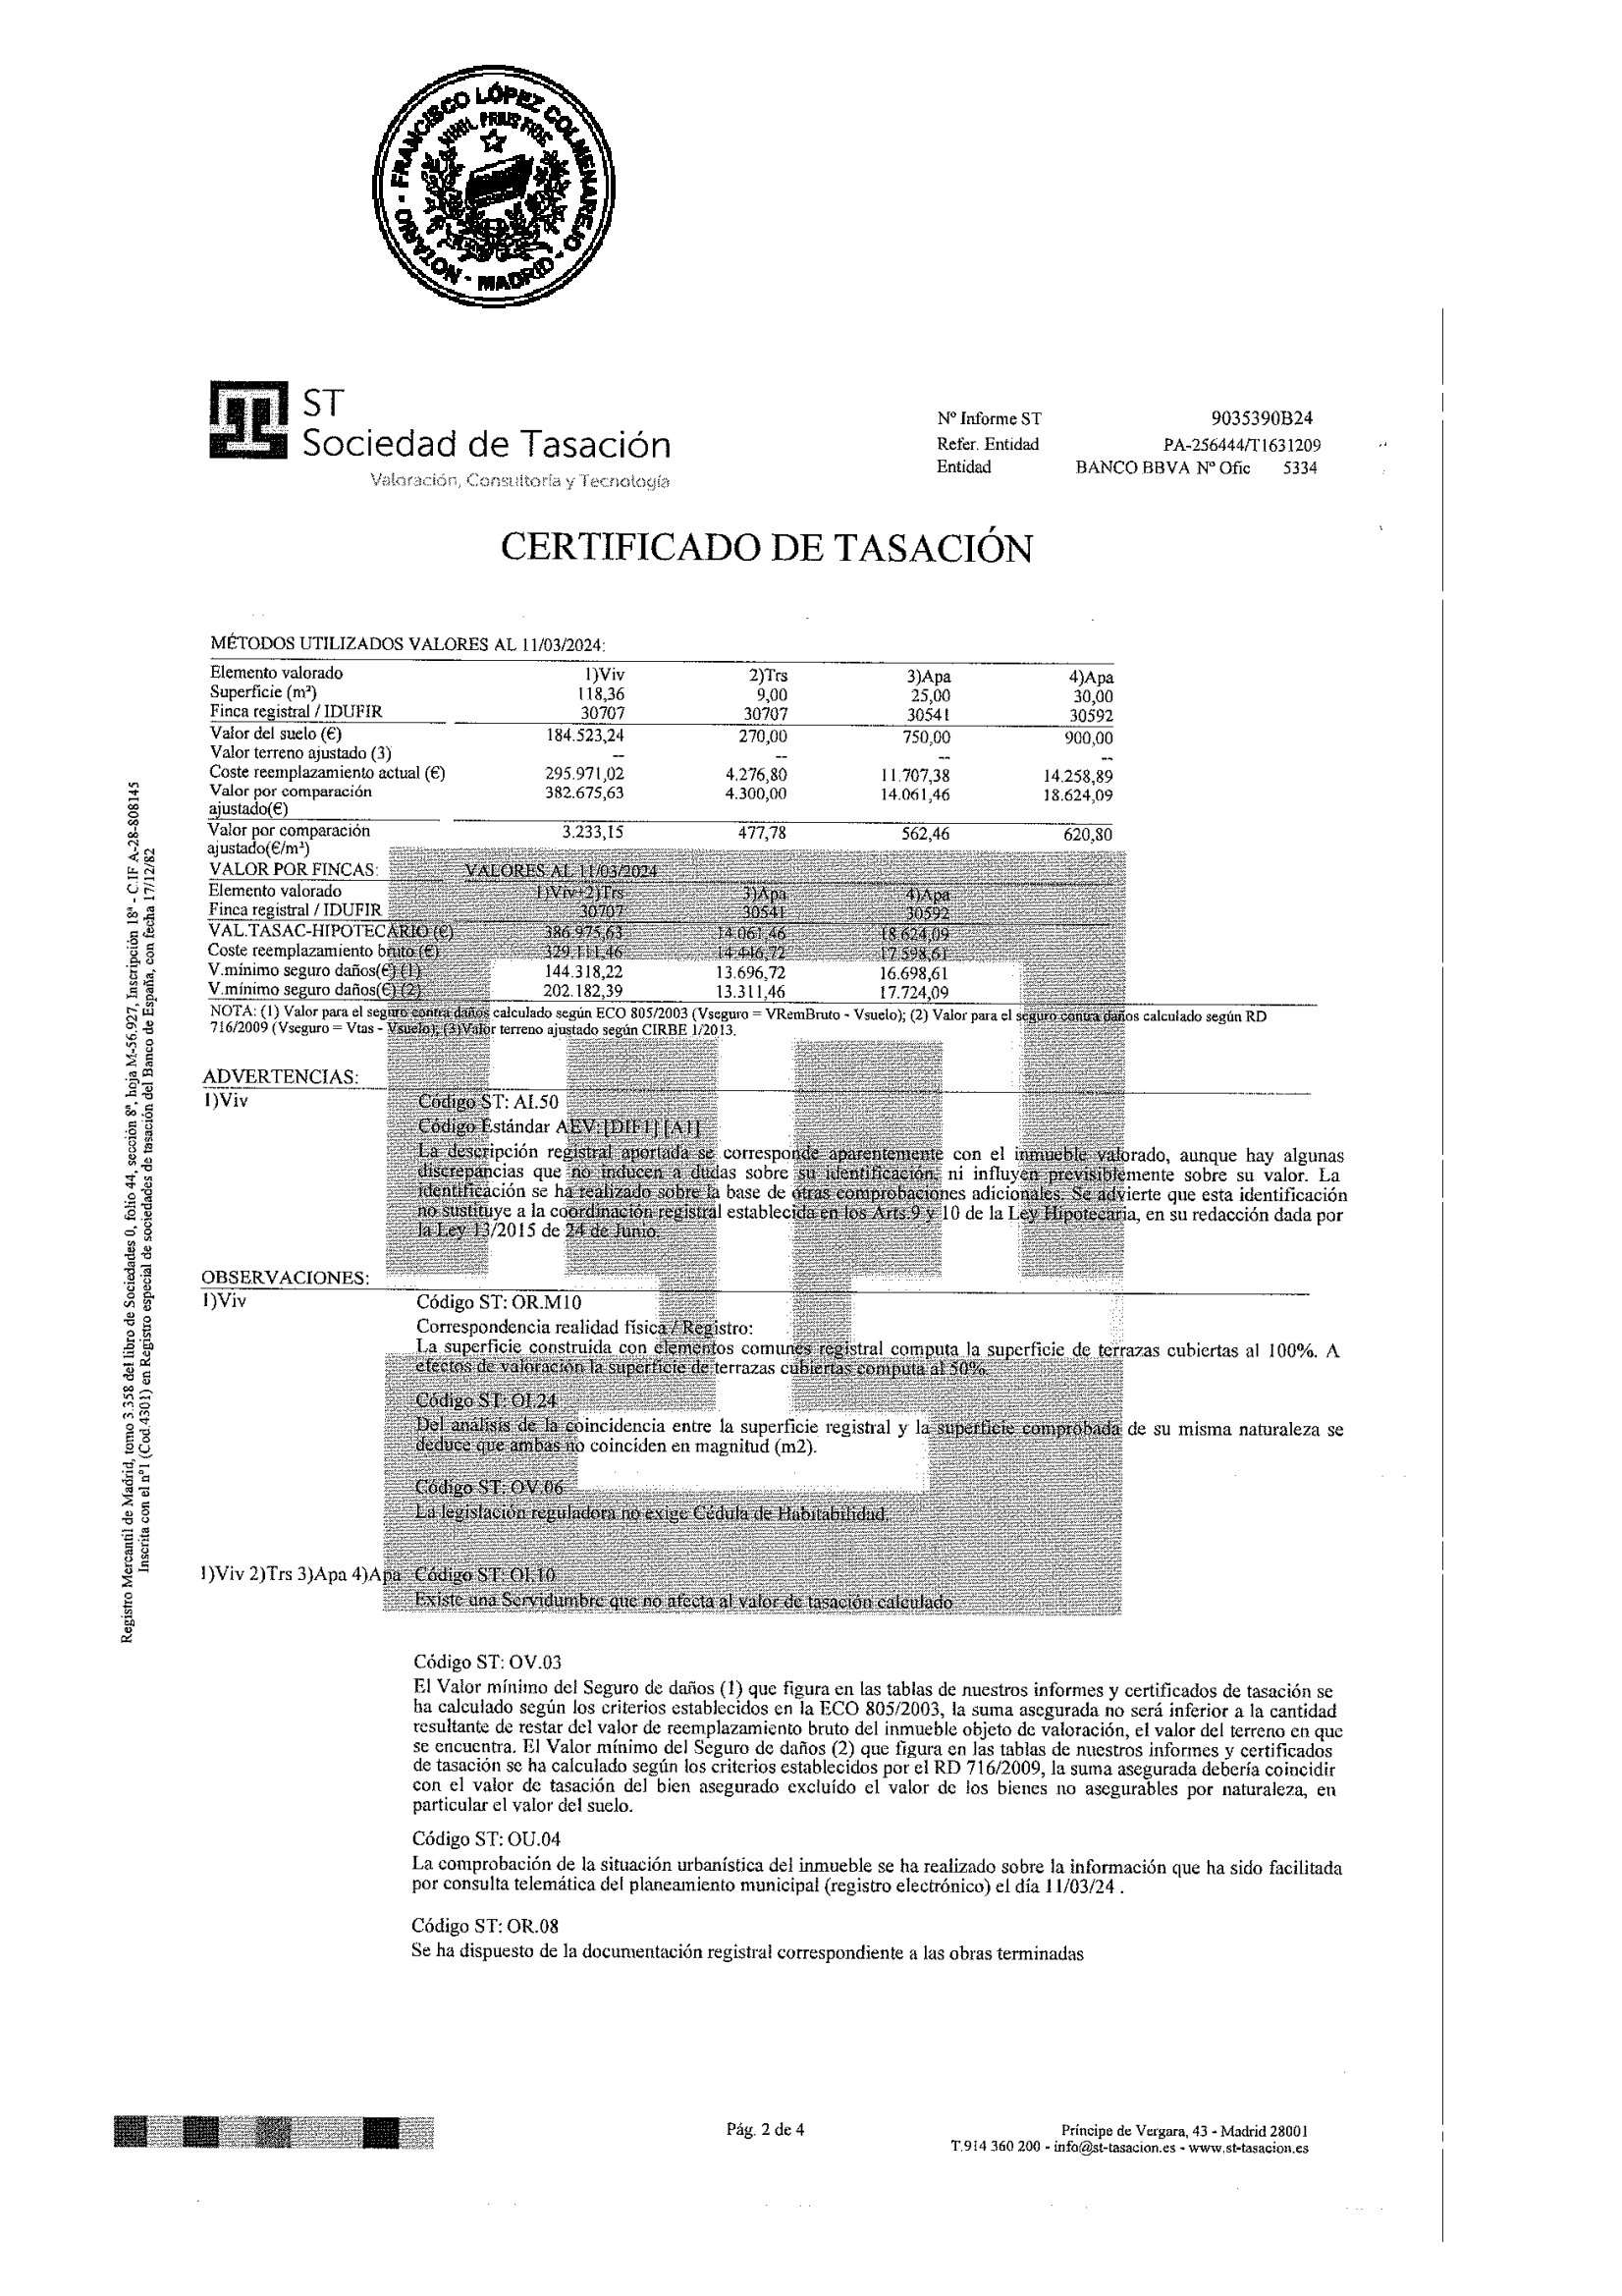

In [5]:
img = Image.open(io.BytesIO(screenshot.get_page(105).image_bytes))
img = img.rotate(0, expand=True)
display(img)

## 2. Detección de PII con Presidio + recognizers específicos de España

Presidio actúa como orquestador. No delegamos todo en un solo modelo: combinamos reglas deterministas para identificadores y patrones claros con un LLM local para entidades menos estructuradas.

En este notebook usamos tres capas:
- **SpanishIDRecognizer** para DNI, NIF, NIE y CIF con validación de dígito de control mediante `pydni`
- **GemmaLLMRecognizer** para personas, organizaciones, direcciones y ubicaciones
- **PatternRecognizer** para email, teléfono, URL y código postal

La idea es simple: usar el método más fiable para cada tipo de dato, no forzar un único detector para todo.


In [20]:
# --- Custom Recognizer: DNI/NIF/NIE/CIF con pydni ---
class SpanishIDRecognizer(EntityRecognizer):
    def __init__(self):
        super().__init__(supported_entities=["ES_DNI", "ES_NIE", "ES_CIF"], supported_language="es")
        self.dni_re = re.compile(r"\b\d{8}[\s\-]?[A-Z]\b")
        self.nie_re = re.compile(r"\b[XYZ][\s\-]?\d{7}[\s\-]?[A-Z]\b")
        self.cif_re = re.compile(r"\b[A-HJ-NP-SUVW][\.\ -]?\d{2}[\.\ -]?\d{6}\b|\b[A-HJ-NP-SUVW]-?\d{7}-?[A-Z0-9]\b")
    def load(self): pass
    def _clean(self, v): return v.upper().replace("-", "").replace(" ", "").replace(".", "")
    def analyze(self, text, entities, nlp_artifacts=None, regex_flags=None):
        results = []
        for m in self.dni_re.finditer(text):
            if verificar_dni(self._clean(m.group(0))):
                results.append(RecognizerResult("ES_DNI", m.start(), m.end(), 1.0))
        for m in self.nie_re.finditer(text):
            if verificar_nie(self._clean(m.group(0))):
                results.append(RecognizerResult("ES_NIE", m.start(), m.end(), 1.0))
        for m in self.cif_re.finditer(text):
            if verificar_cif(self._clean(m.group(0))):
                results.append(RecognizerResult("ES_CIF", m.start(), m.end(), 1.0))
        return results


# --- Custom Recognizer: LLM local (gemma-4-26b) via LangChain structured output ---
class PIIEntities(BaseModel):
    """PII entities extracted from text."""
    personas: list[str] = Field(default_factory=list, description="Full names of persons")
    organizaciones: list[str] = Field(default_factory=list, description="Company/organization names")
    direcciones: list[str] = Field(default_factory=list, description="Full postal addresses")
    ubicaciones: list[str] = Field(default_factory=list, description="Cities, provinces, countries")


class GemmaLLMRecognizer(EntityRecognizer):
    LABEL_MAP = {
        "personas": "PERSON",
        "organizaciones": "ORGANIZATION",
        "direcciones": "ADDRESS",
        "ubicaciones": "LOCATION",
    }

    SYSTEM_PROMPT = (
        "Extrae toda la información personal identificable (PII) del texto. "
        "Solo nombres reales de personas, empresas, lugares y direcciones postales. "
        "No incluyas términos legales, códigos técnicos, fórmulas ni jerga. "
        "Ignora etiquetas HTML y sintaxis markdown."
    )

    def __init__(self):
        super().__init__(
            supported_entities=list(set(self.LABEL_MAP.values())),
            supported_language="es",
        )
        self._cache = {}
        self._llm = None

    def _get_llm(self):
        if self._llm is None:
            self._llm = ChatOllama(
                base_url=OLLAMA_URL,
                model=LLM_MODEL,
                temperature=0,
                num_ctx=16384,
            ).with_structured_output(PIIEntities)
        return self._llm

    def load(self): pass

    def _clean_html(self, t):
        t = re.sub(r"<[^>]+>", " ", t)
        t = re.sub(r"!\\[.*?\\]\\(.*?\\)", "", t)
        t = re.sub(r"\\[.*?\\]\\(.*?\\)", "", t)
        return re.sub(r"\s+", " ", t).strip()

    def _call_llm(self, text):
        cache_key = hash(text)
        if cache_key in self._cache:
            return self._cache[cache_key]

        clean = self._clean_html(text)
        try:
            result = self._get_llm().invoke([
                {"role": "system", "content": self.SYSTEM_PROMPT},
                {"role": "user", "content": clean},
            ])
            data = result.model_dump()
        except Exception as e:
            print(f"GemmaLLMRecognizer error: {type(e).__name__}: {e}")
            data = {}

        self._cache[cache_key] = data
        return data

    def analyze(self, text, entities, nlp_artifacts=None, regex_flags=None):
        data = self._call_llm(text)
        results = []
        seen = set()
        for key, mapped in self.LABEL_MAP.items():
            if mapped not in entities:
                continue
            for value in data.get(key, []):
                if not isinstance(value, str) or len(value) < 4 or value in seen:
                    continue
                seen.add(value)
                idx = text.find(value)
                if idx != -1:
                    results.append(RecognizerResult(mapped, idx, idx + len(value), 0.85))
        return results


# --- Regex recognizers ---
email_rec = PatternRecognizer(supported_entity="EMAIL_ADDRESS", supported_language="es",
    patterns=[Pattern("email", r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", 0.9)])
url_rec = PatternRecognizer(supported_entity="URL", supported_language="es",
    patterns=[Pattern("url", r"(?:https?://|www\.)[^\s,]+", 0.5)])
cp_rec = PatternRecognizer(supported_entity="POSTAL_CODE", supported_language="es",
    patterns=[Pattern("cp_es", r"\b(?:0[1-9]|[1-4]\d|5[0-2])\d{3}\b", 0.1)],
    context=["CP", "C.P.", "código postal", "Madrid", "Barcelona", "Sevilla", "Valencia"])
phone_rec = PatternRecognizer(supported_entity="PHONE_NUMBER", supported_language="es",
    patterns=[Pattern("phone_es", r"\b(?:\+34[\s.-]?)?(?:\d{3}[\s.-]?\d{3}[\s.-]?\d{3}|\d{2}[\s.-]?\d{3}[\s.-]?\d{2}[\s.-]?\d{2})\b", 0.7)])


# --- Construir Presidio ---
registry = RecognizerRegistry(supported_languages=["es"])
registry.add_recognizer(SpanishIDRecognizer())
registry.add_recognizer(GemmaLLMRecognizer())
registry.add_recognizer(email_rec)
registry.add_recognizer(url_rec)
registry.add_recognizer(phone_rec)
registry.add_recognizer(cp_rec)

nlp_config = {"nlp_engine_name": "spacy", "models": [{"lang_code": "es", "model_name": "es_core_news_sm"}]}
nlp_engine = NlpEngineProvider(nlp_configuration=nlp_config).create_engine()

analyzer = AnalyzerEngine(registry=registry, nlp_engine=nlp_engine, supported_languages=["es"])
anonymizer = AnonymizerEngine()


# --- Anonimización reversible con tokens numerados ---
class ReversibleAnonymizer:
    """Anonimiza con tokens numerados (<PERSONA_1>, <ORG_2>) y guarda el mapeo para revertir."""
    def __init__(self):
        self.mapping = {}       # token -> valor original
        self._counters = {}     # entity_type -> counter
        self._seen = {}         # valor original -> token (para consistencia)

    def _get_token(self, entity_type, original):
        if original in self._seen:
            return self._seen[original]
        count = self._counters.get(entity_type, 0) + 1
        self._counters[entity_type] = count
        token = f"<{entity_type}_{count}>"
        self.mapping[token] = original
        self._seen[original] = token
        return token

    def anonymize(self, text, analyzer_results):
        """Reemplaza PII por tokens numerados, devuelve texto anonimizado."""
        # Ordenar de derecha a izquierda para no romper offsets
        sorted_results = sorted(analyzer_results, key=lambda x: x.start, reverse=True)
        out = text
        for r in sorted_results:
            original = text[r.start:r.end]
            token = self._get_token(r.entity_type, original)
            out = out[:r.start] + token + out[r.end:]
        return out

    def deanonymize(self, text):
        """Reemplaza tokens por valores originales."""
        out = text
        for token, original in self.mapping.items():
            out = out.replace(token, original)
        return out

rev_anonymizer = ReversibleAnonymizer()


## 3. Anonimización reversible en local

Con las entidades detectadas, sustituimos cada valor por un token estable y numerado. Así el modelo puede razonar sobre relaciones entre entidades sin ver nombres, direcciones o identificadores reales.

Ejemplo:
- `BANCO BBVA` -> `<ORGANIZATION_1>`
- `Príncipe de Vergara, 43 - Madrid 28001` -> `<ADDRESS_1>`

El mapeo se guarda en local para poder reconstruir la respuesta al final.


In [21]:
# Analizar con Presidio (regex + LLM local + patterns)
results = analyzer.analyze(text=content, language="es", score_threshold=0.25)

# Mostrar entidades detectadas
print(f"Detectadas {len(results)} entidades:\n")
for r in sorted(results, key=lambda x: x.start):
    print(f"  {r.entity_type}: \"{content[r.start:r.end]}\" (score: {r.score:.2f})")

# Anonimizar con tokens reversibles
anonymized_text = rev_anonymizer.anonymize(content, results)
print(f"\n--- Texto anonimizado ---\n")
print(anonymized_text)

# Mostrar mapeo
print(f"\n--- Mapeo de anonimización ({len(rev_anonymizer.mapping)} tokens) ---\n")
for token, original in rev_anonymizer.mapping.items():
    print(f"  {token} → {original}")


Detectadas 7 entidades:

  ORGANIZATION: "ST Sociedad de Tasación" (score: 0.85)
  LOCATION: "Madrid" (score: 0.85)
  LOCATION: "28001" (score: 0.85)
  POSTAL_CODE: "28001" (score: 0.45)
  PHONE_NUMBER: "914 367 202" (score: 0.70)
  EMAIL_ADDRESS: "info@st-otm.com.es" (score: 0.90)
  URL: "www.st-otm.com.es" (score: 0.50)

--- Texto anonimizado ---

 No se ha incluido ningún comentario ni explicaciones.

---

**<ORGANIZATION_1>**

*Valores, Comunidades y Tecnología*

Nº Informe ST: PA-25644/T 1/03/2024  
Refer. Entidad: BARCO BUVA N° Ofic: 5334  
Posición:  

---

# CERTIFICADO DE TASACIÓN

## MÉTODOS UTILIZADOS VALORES AL 11/03/2024:

<table>
  <tr>
    <th>Elemento valorado</th>
    <td>TIVvs</td>
    <td>23798</td>
    <td>31Apa</td>
    <td>43Apa</td>
  </tr>
  <tr>
    <th>Superficie (m²)</th>
    <td>116.26</td>
    <td>900</td>
    <td>25.00</td>
    <td>30.00</td>
  </tr>
  <tr>
    <th>Peso capital / IDUFIR</th>
    <td>32707</td>
    <td>32797</td>
    <td>85641</td>
    <td>

## 4. LLM cloud sobre texto ya desidentificado

Solo en este punto enviamos el contenido a un modelo cloud, y lo hacemos con el texto ya anonimizado. El modelo ve tokens como `<ORGANIZATION_1>` o `<ADDRESS_1>`, no el dato real.

Después de obtener la respuesta:
1. mantenemos el análisis sobre el texto anonimizado
2. revertimos los tokens con el mapeo local
3. devolvemos un resultado legible para el equipo

Es la diferencia entre usar un LLM sobre documentación sensible y usarlo con una capa de control previa.


In [8]:
model = ChatOpenRouter(
    model="z-ai/glm-5.1",
    temperature=0.8,
    api_key=os.environ.get("OPENROUTER_API_KEY"),
)

In [9]:
# Usar Presidio como detector en PIIMiddleware
def detect_all_pii(content: str) -> list[dict]:
    results = analyzer.analyze(text=content, language="es", score_threshold=0.25)
    return [
        {"text": content[r.start:r.end], "start": r.start, "end": r.end}
        for r in results
    ]

agent = create_agent(
    model=model,
    tools=[],
    middleware=[
        PIIMiddleware("pii", detector=detect_all_pii, strategy="redact"),
    ],
)

# Enviar texto anonimizado (con tokens reversibles) al LLM
result = agent.invoke({
    "messages": [
        {
            "role": "system",
            "content": """Eres un analista de riesgos de un banco.
Te voy a dar un certificado de tasación inmobiliaria con datos anonimizados.
Los tokens como <PERSONA_1>, <ORG_2> representan entidades reales — puedes referirte a ellos.
Analiza inconsistencias, riesgos y si aceptarías esta tasación."""
        },
        {
            "role": "user",
            "content": anonymized_text
        }
    ]
})


In [10]:
# Lo que el LLM realmente recibió (entrada redactada)
print(result["messages"][1].content)

 No se ha incluido ningún comentario ni explicaciones.

---

**<ORGANIZATION_1>**

*Valores, Comunidades y Tecnología*

Nº Informe ST: PA-25644/T 1/03/2024  
Refer. Entidad: BARCO BUVA N° Ofic: 5334  
Posición:  

---

# CERTIFICADO DE TASACIÓN

## MÉTODOS UTILIZADOS VALORES AL 11/03/2024:

<table>
  <tr>
    <th>Elemento valorado</th>
    <td>TIVvs</td>
    <td>23798</td>
    <td>31Apa</td>
    <td>43Apa</td>
  </tr>
  <tr>
    <th>Superficie (m²)</th>
    <td>116.26</td>
    <td>900</td>
    <td>25.00</td>
    <td>30.00</td>
  </tr>
  <tr>
    <th>Peso capital / IDUFIR</th>
    <td>32707</td>
    <td>32797</td>
    <td>85641</td>
    <td>80992</td>
  </tr>
  <tr>
    <th>Válor del suelo (€)</th>
    <td>134.52,24</td>
    <td>27000</td>
    <td>75000</td>
    <td>90000</td>
  </tr>
  <tr>
    <th>Válor interno (gustado) (t)</th>
    <td></td>
    <td></td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <th>Código correspondiente actual (€)</th>
    <td>205.971,02</td>
    <td>4.276,8

In [11]:
# Respuesta del LLM (anonimizada)
llm_response = result["messages"][-1].content
print("--- Respuesta anonimizada ---")
display(Markdown(llm_response[:500]))

# Deanonimizar la respuesta
print("\n--- Respuesta deanonimizada ---")
deanonymized = rev_anonymizer.deanonymize(llm_response)
display(Markdown(deanonymized[:500]))


--- Respuesta anonimizada ---


Como analista de riesgos, tras revisar el certificado de tasación emitido por `<ORGANIZATION_1>`, debo concluir que el documento presenta anomalías críticas que comprometen gravemente su fiabilidad, validez jurídica y utilidad para la garantía hipotecaria. 

A continuación, detallo el análisis de inconsistencias, riesgos y la resolución final:

### 1. Inconsistencias Críticas (Banderas Rojas)

*   **Inconsistencia temporal irresoluble:** El informe lleva fecha de emisión del **01/03/2024**, pero


--- Respuesta deanonimizada ---


Como analista de riesgos, tras revisar el certificado de tasación emitido por `ST Sociedad de Tasación`, debo concluir que el documento presenta anomalías críticas que comprometen gravemente su fiabilidad, validez jurídica y utilidad para la garantía hipotecaria. 

A continuación, detallo el análisis de inconsistencias, riesgos y la resolución final:

### 1. Inconsistencias Críticas (Banderas Rojas)

*   **Inconsistencia temporal irresoluble:** El informe lleva fecha de emisión del **01/03/2024*